# **Multimodal RAG: Retrieval Augmented Generation over Text *and* Images**

### **What is Multimodal RAG?**

Standard RAG retrieves and reasons over **text only**. But real knowledge bases are full of **images** — product photos, charts, diagrams, screenshots, scanned pages.

**Multimodal RAG** extends the same idea to images: we retrieve the most relevant *images* for a query and let a **vision-capable LLM** look at them to produce a grounded answer.

### **Why do we need it?**

> A text-only RAG system is blind.

If the answer lives inside a picture — *"which of these products looks rugged enough for travel?"* — a text pipeline simply can't help. Multimodal RAG lets the model *see* the evidence before it answers.

### **How is it different from text RAG?**

Only two pieces of the pipeline change — everything else (Qdrant, the 3-act structure) stays exactly the same as the text RAG you already built.

| Stage | Text RAG | Multimodal RAG |
|---|---|---|
| Embedding | text encoder (MiniLM) | **CLIP** — text *and* images in one shared space |
| Generation | text LLM | **Vision LLM** (Llama 4 Scout) that can read images |

The magic is the **shared embedding space**: CLIP maps a text query and an image into the *same* vector space, so a plain text question can retrieve relevant **images** directly.

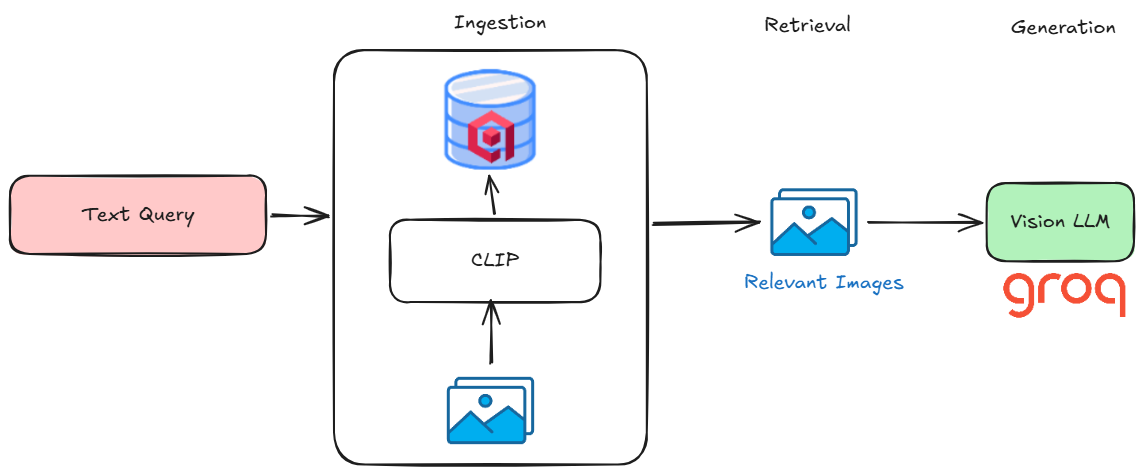

### **What are we going to build?**

An **AtliqAI Product Catalog Assistant** — ask a question in plain text and it finds the right product images, then describes and recommends based on what it actually sees.

In [1]:
!pip install -q qdrant-client sentence-transformers groq pandas requests pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 8.1 MB/s eta 0:00:00


## **Act 1 — Ingestion**

Just like text RAG, ingestion means getting our data into the vector DB:

- **Loading** — download the catalog images + their metadata
- **Embedding** — turn each image into a CLIP vector
- **Indexing** — store the vectors (and payload) in Qdrant

> Note: there is **no chunking** step here. An image is already an atomic unit — we embed the whole image as-is.

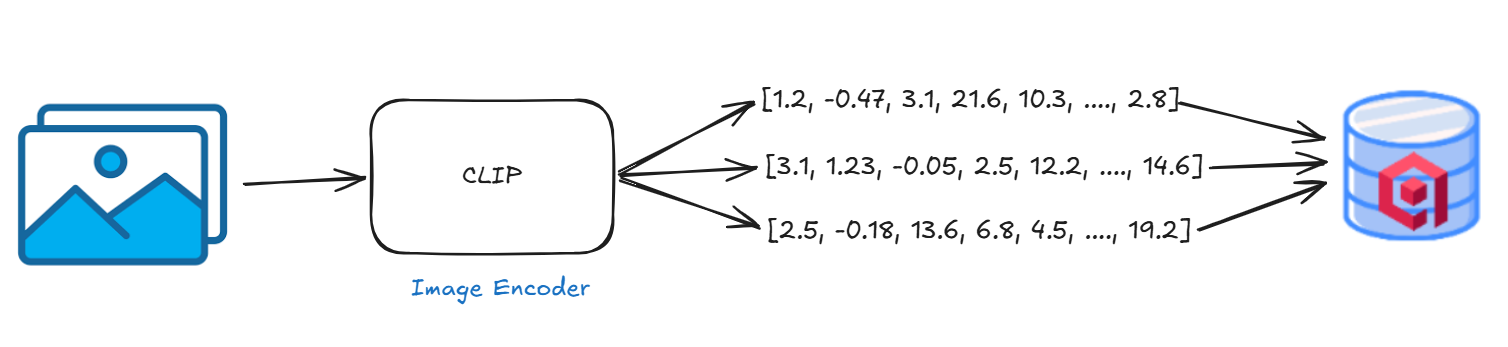

### **Loading the catalog**

The product catalog lives in a local `catalog/` folder next to this notebook:

```
catalog/
├── metadata.csv          # columns: filename, caption, category
└── images/
    ├── laptop_pro.jpg
    ├── office_chair.jpg
    └── ...
```

`metadata.csv` gives each image a short caption and a category. We read it and load each image straight from the `images/` folder.

In [2]:
import os
import zipfile
import pandas as pd

CATALOG_DIR = "catalog"

if not os.path.isdir(CATALOG_DIR):
    try:
        from google.colab import files
        print("Running in Colab – please upload catalog.zip")
        uploaded = files.upload()          # interactive file picker
        zip_name = next(iter(uploaded))    # first (and only) uploaded file
        with zipfile.ZipFile(zip_name, "r") as zf:
            zf.extractall(".")             # extracts into ./catalog/
        print(f"Extracted {zip_name} → ./{CATALOG_DIR}/")
    except ImportError:
        raise FileNotFoundError(
            f"./{CATALOG_DIR}/ not found and not running in Colab. "
            "Place the catalog folder next to this notebook."
        )

metadata = pd.read_csv(os.path.join(CATALOG_DIR, "metadata.csv"))
metadata["path"] = metadata["filename"].apply(
    lambda fn: os.path.join(CATALOG_DIR, "images", fn)
)

print(f"Loaded {len(metadata)} catalog items from ./{CATALOG_DIR}/")
print(metadata[["filename", "category"]].head())


Running in Colab – please upload catalog.zip


Saving catalog.zip to catalog.zip
Extracted catalog.zip → ./catalog/
Loaded 15 catalog items from ./catalog/
                  filename     category
0           laptop_pro.jpg  Electronics
1           monitor_27.jpg  Electronics
2  mechanical_keyboard.jpg  Electronics
3       wireless_mouse.jpg  Electronics
4           headphones.jpg  Electronics


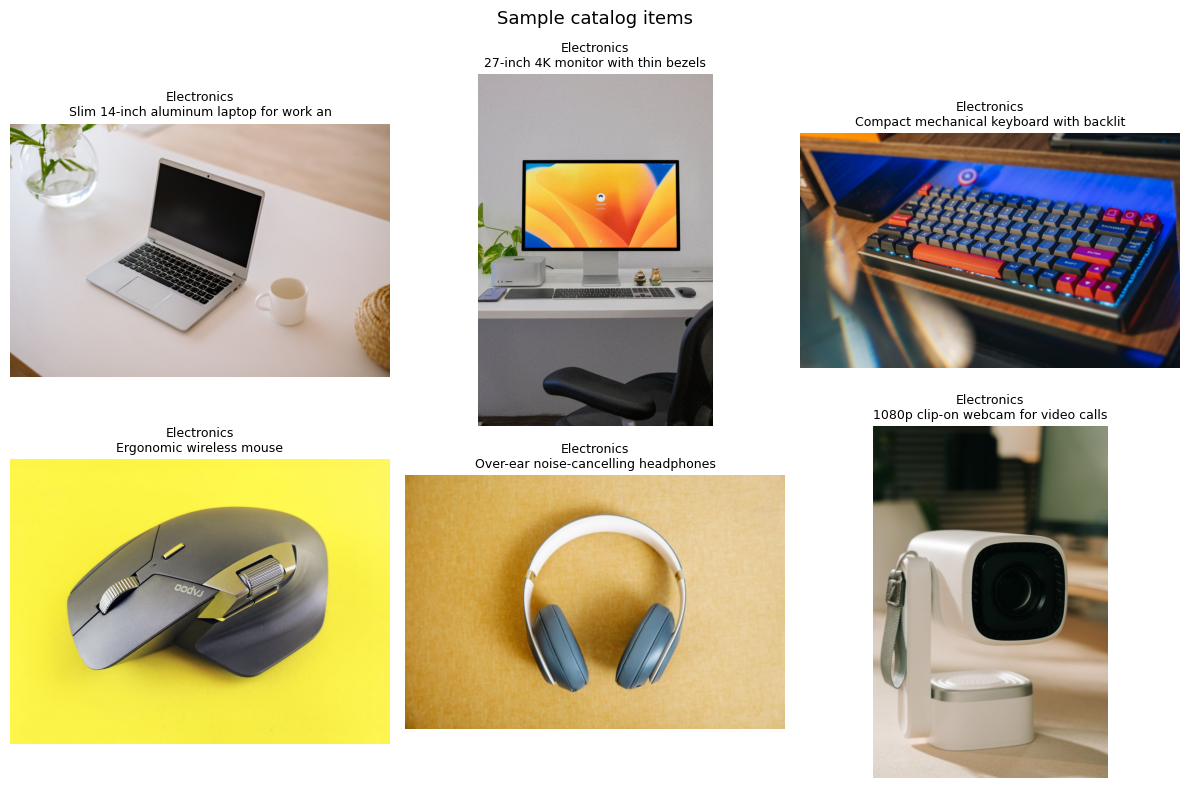

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

def show_images(rows, title=None, cols=3):
    """Display catalog images in a grid (works inline on Colab)."""
    rows = rows.reset_index(drop=True)
    n = len(rows)
    ncols = min(cols, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = list(axes.flatten()) if n > 1 else [axes]
    for ax in axes:
        ax.axis("off")
    for i, row in rows.iterrows():
        axes[i].imshow(Image.open(row["path"]))
        axes[i].set_title(f"{row['category']}\n{row['caption'][:40]}", fontsize=9)
    if title:
        fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

show_images(metadata.head(6), title="Sample catalog items")

### **Embedding — meet CLIP**

**CLIP** (Contrastive Language–Image Pre-training) was trained on millions of (image, caption) pairs to place an image and its description **close together in the same vector space**.

That single property is what makes multimodal retrieval possible:

> A text query and a matching image end up as **nearby vectors** — so we can search images using words.

We load CLIP through `sentence-transformers`, exactly like the text embedder from earlier sessions — same API, just a multimodal model.

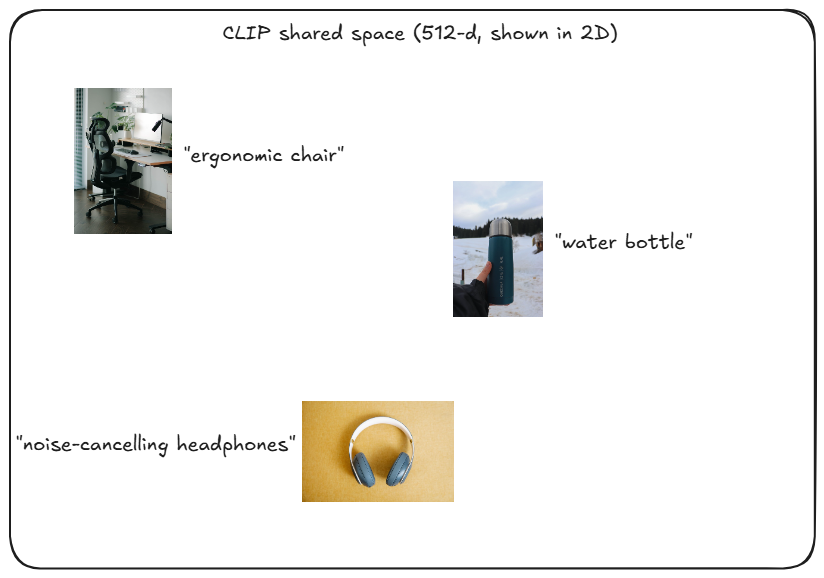

In [4]:
from sentence_transformers import SentenceTransformer

# CLIP encodes BOTH text and images with the same .encode() call
clip = SentenceTransformer("clip-ViT-B-32")

# Proof that text and images live in the same space → identical dimensionality
sample_image = Image.open(metadata.iloc[0]["path"])
img_vec  = clip.encode(sample_image)
text_vec = clip.encode("a product photo")

print(f"Image vector shape : {img_vec.shape}")
print(f"Text  vector shape : {text_vec.shape}")
print("Same dimension → text and images are directly comparable ✅")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Image vector shape : (512,)
Text  vector shape : (512,)
Same dimension → text and images are directly comparable ✅


In [5]:
# Load every image and embed it with CLIP
images = [Image.open(p) for p in metadata["path"]]

print(f"Embedding {len(images)} images with CLIP …")
image_embeddings = clip.encode(images, show_progress_bar=True)

print(f"Shape: {image_embeddings.shape}")   # → (N, 512)

Embedding 15 images with CLIP …


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Shape: (15, 512)


In [6]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

# path= → local, no server needed (perfect for Colab)
client = QdrantClient(path="/tmp/qdrant_multimodal")

COLLECTION_NAME = "catalog"
DIM = image_embeddings.shape[1]   # CLIP → 512

client.recreate_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(size=DIM, distance=Distance.COSINE),
)

# One point per image; payload carries everything we need to answer + display
points = [
    PointStruct(
        id=idx,
        vector=embedding.tolist(),
        payload={
            "filename": row["filename"],
            "caption":  row["caption"],
            "category": row["category"],
            "path":     row["path"],
        },
    )
    for idx, (embedding, (_, row)) in enumerate(zip(image_embeddings, metadata.iterrows()))
]

client.upsert(collection_name=COLLECTION_NAME, points=points, wait=True)
print(f"Indexed {len(points)} images into Qdrant collection '{COLLECTION_NAME}'")

/tmp/ipykernel_4644/1578921184.py:10: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


Indexed 15 images into Qdrant collection 'catalog'


In [7]:
info = client.get_collection(COLLECTION_NAME)
print(f"Points     : {info.points_count}")
print(f"Dimensions : {info.config.params.vectors.size}")

Points     : 15
Dimensions : 512


## **Act 2 — Retrieval**

Now the payoff of the shared space: we embed the **text query** with the *same* CLIP model and search against the **image** vectors.

> Text in → images out. No captions, no keywords — pure cross-modal search.

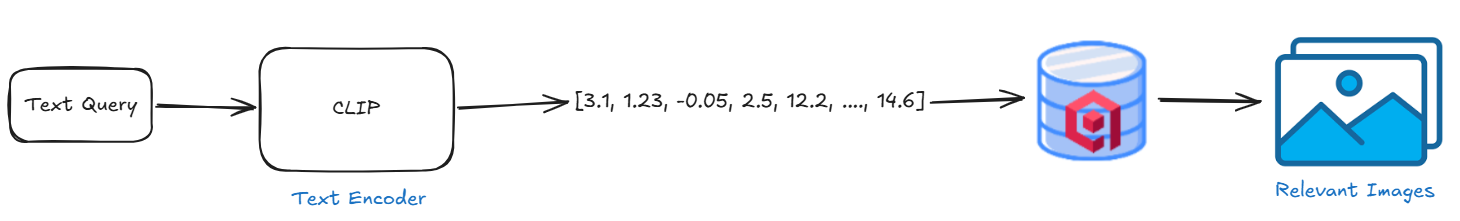

In [8]:
def retrieve(query: str, top_k: int = 3) -> list[dict]:
    """Embed the text query with CLIP and return the top-k most similar images."""
    query_vector = clip.encode(query).tolist()

    hits = client.query_points(
        collection_name=COLLECTION_NAME,
        query=query_vector,
        limit=top_k,
        with_payload=True,
    )

    return [{**hit.payload, "score": round(hit.score, 4)} for hit in hits.points]

[0.2892]  Furniture — Mesh-back ergonomic office chair with lumbar support
[0.2843]  Furniture — Cushioned under-desk footrest
[0.2464]  Electronics — Adjustable LED desk lamp with warm light


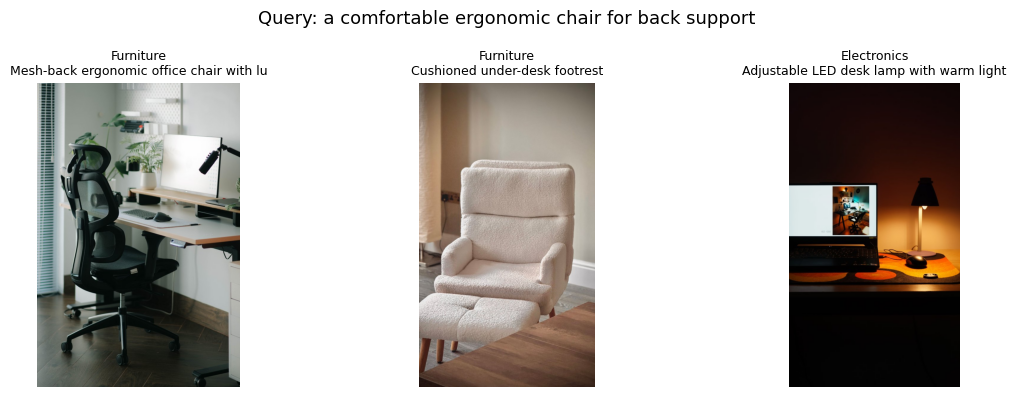

In [9]:
query = "a comfortable ergonomic chair for back support"
results = retrieve(query, top_k=3)

for r in results:
    print(f"[{r['score']}]  {r['category']} — {r['caption']}")

# Show what came back — visual proof that a text query retrieved the right images
show_images(pd.DataFrame(results), title=f"Query: {query}")

## **Act 3 — Generation with a Vision LLM**

Retrieval gives us the right images. Now we hand those images to a **vision-capable LLM** and ask it to answer using what it sees.

We use **Llama 4 Scout** on **Groq** — a multimodal model on the same free Groq stack we've used all along. Images are sent as base64 **data URLs** inside the chat message.

### **Setting up Groq**
1. Visit https://console.groq.com/keys
2. Create an account and click **Create API Key**
3. Copy the key and paste it into the prompt below

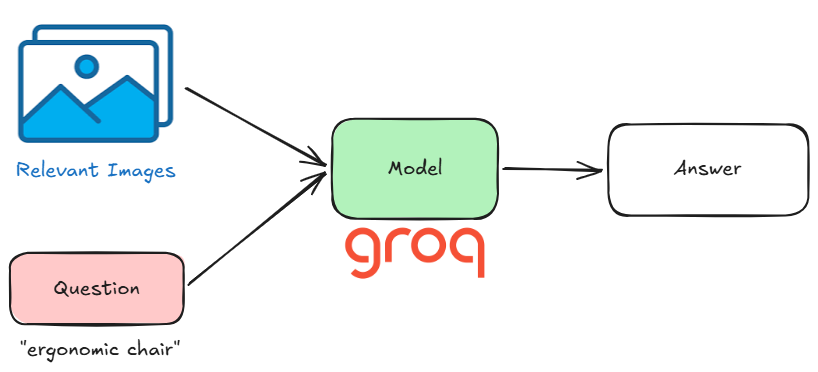

In [10]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [11]:
import base64
import mimetypes

def image_to_data_url(path: str) -> str:
    """Encode a local image as a base64 data URL the vision model can read."""
    mime = mimetypes.guess_type(path)[0] or "image/jpeg"
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

### **End-to-end Multimodal RAG pipeline**
1. **Retrieve** the most relevant images for the query
2. **Attach** those images (as data URLs) to the prompt
3. **Generate** — ask the vision LLM to answer using what it sees

In [12]:
from groq import Groq

groq_client = Groq()   # reads GROQ_API_KEY from the environment automatically
VISION_MODEL = "meta-llama/llama-4-scout-17b-16e-instruct"

SYSTEM_PROMPT = (
    "You are AtliqAI's helpful product catalog assistant. "
    "Answer the customer's question using ONLY the product images provided. "
    "Describe what you actually see and recommend the best match. "
    "If none of the images fit the request, say so honestly."
)

def multimodal_rag(query: str, top_k: int = 3):
    """
    End-to-end Multimodal RAG:
      1. Retrieve relevant images from Qdrant
      2. Attach them to a multimodal prompt
      3. Generate a grounded answer with the vision LLM
    """
    # Step 1 — Retrieve relevant images
    results = retrieve(query, top_k=top_k)
    if not results:
        return "No relevant products found.", results

    # Step 2 — Build a multimodal message: the text question + the retrieved images
    content = [{"type": "text", "text": f"Customer question: {query}"}]
    for r in results:
        content.append({
            "type": "image_url",
            "image_url": {"url": image_to_data_url(r["path"])},
        })

    # Step 3 — Generate a grounded answer with the vision LLM
    response = groq_client.chat.completions.create(
        model=VISION_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": content},
        ],
        temperature=0.2,   # low = factual
    )
    return response.choices[0].message.content, results

Based on the images provided, I see a home office setup with a desk, chair, monitor, keyboard, and mouse. 

The most essential item for someone setting up a home office would be a comfortable and ergonomic chair, as seen in the first image. This appears to be a high-quality office chair with adjustable features and a breathable mesh back. 

I recommend the office chair as the best match for someone setting up a home office.
Products the assistant looked at:


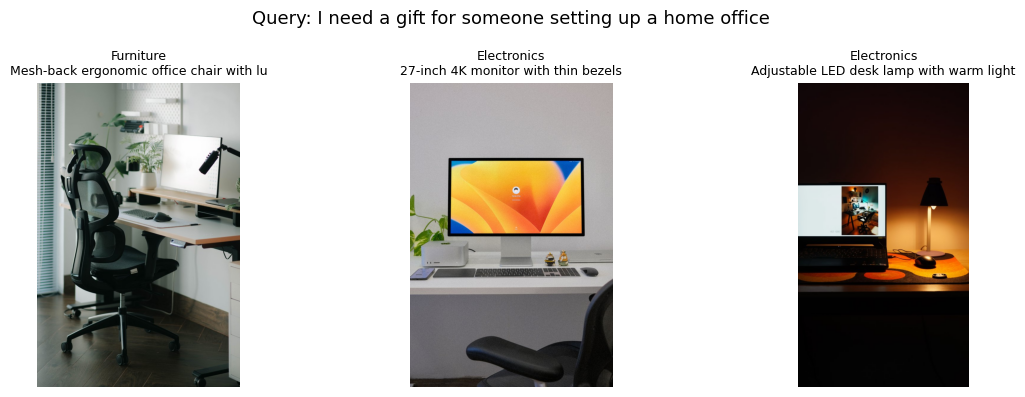

In [13]:
query = "I need a gift for someone setting up a home office"
answer, sources = multimodal_rag(query)

print(answer)
print("=" * 80)
print("Products the assistant looked at:")
show_images(pd.DataFrame(sources), title=f"Query: {query}")

### **✏️ Exercises**

- **Image-to-image search:** embed an uploaded image with CLIP and retrieve visually similar catalog items.
- **Hybrid catalog:** also index the text captions and combine text + image retrieval.
- **Captioning approach:** use the vision LLM to caption each image, embed the captions, and compare retrieval quality against CLIP.
- **Metadata filters:** restrict search to a single `category` using Qdrant filters (see Session 3).